In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax
RNG_SEED = 42

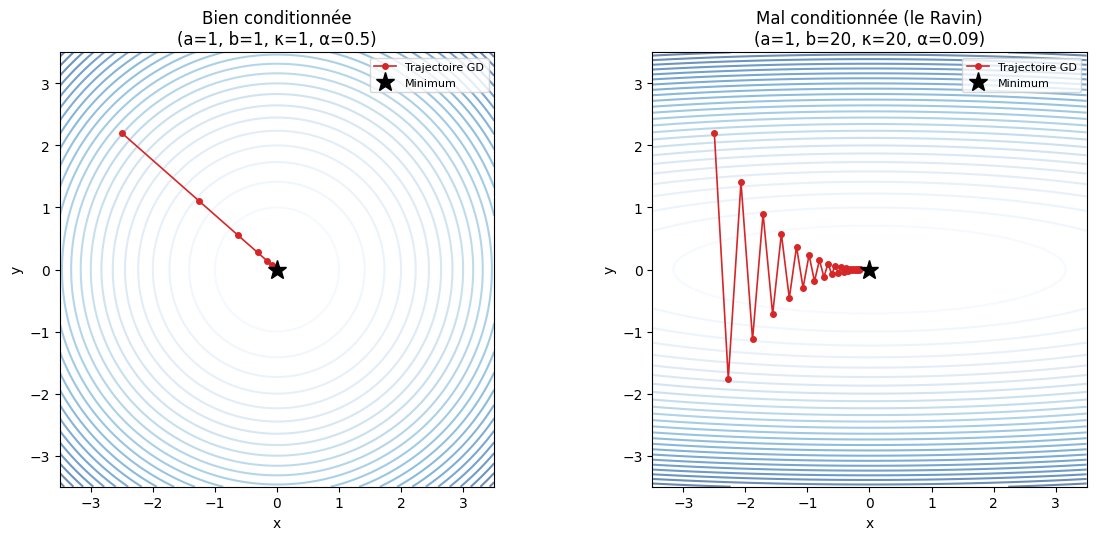

=== Exercice 5 : Power Iteration ===
sigma_1 (power iteration, 100 itérations) : 12.44177201512584219
sigma_1 (np.linalg.svd, référence)         : 12.44177201512735742
Écart absolu                                : 1.52e-12

=== Exercice 6 : Self-Attention ===
Dimension de S = Q K^T : (4, 4)  (attendu : (N, N) = (4, 4))
Somme de chaque ligne de A (doit valoir 1) : [1. 1. 1. 1.]

Ligne 1 de Z (sortie contextualisée du mot 1) :
[-0.76739168 -0.28251374 -0.21182414]

Comparaison avec les lignes de V (les 'valeurs' de chaque mot) :
[[ 1.4133953  -1.39494684 -1.94893526]
 [ 3.75043744 -0.49002261 -1.61083956]
 [ 0.53305314 -0.23263959 -0.4086622 ]
 [-2.63117698  0.23491399  0.78850666]]

Poids d'attention du mot 1 envers les 4 mots (ligne 1 de A) :
[0.24514655 0.05052597 0.17376583 0.53056164]

Reconstruction manuelle de Z[0] = somme_j A[0,j] * V[j] :
[-0.76739168 -0.28251374 -0.21182414]
Écart avec Z[0] calculé via A @ V : 0.00e+00


In [3]:

# %% ==========================================================================
# EXERCICE 4 — Visualisation de la malédiction du Conditionnement (le "Ravin")
# ==============================================================================
"""
Énoncé :
--------
Considérez une fonction quadratique de coût f(x, y) = 1/2 (a*x^2 + b*y^2).
Sa matrice Hessienne est diagonale, de valeurs propres a et b.

(a) Le Bol Parfait : fixez a=1, b=1 (conditionnement kappa=1). Tracez les
    lignes de niveau (plt.contour). Implémentez une descente de gradient
    et superposez la trajectoire des poids. Observez la convergence
    rectiligne.

(b) Le Ravin : fixez a=1, b=20 (conditionnement kappa=20). Tracez les lignes
    de niveau (des ellipses étirées). Relancez l'optimisation. Visualisez
    les oscillations destructrices (zig-zag). Expliquez pourquoi un grand
    rapport entre les valeurs propres ruine la dynamique d'apprentissage.

Rappel théorique (cf. Chapitre 2, Définition 2.5 et Remarque 2.2) :
Le conditionnement kappa = lambda_max / lambda_min mesure la "rotondité" de
la surface de coût. Ici la Hessienne est diag(a, b), donc kappa = max(a,b)/min(a,b).
"""


def f(x, y, a, b):
    """
    Fonction de coût quadratique séparable f(x, y) = 1/2 * (a*x^2 + b*y^2).

    Paramètres
    ----------
    x, y : float ou np.ndarray
        Coordonnées du point où évaluer f (peuvent être des grilles pour
        le tracé des lignes de niveau).
    a, b : float
        Coefficients de courbure selon x et selon y. Ce sont exactement
        les deux valeurs propres de la matrice Hessienne de f, puisque
        Hess(f) = [[a, 0], [0, b]] (matrice diagonale, cf. cours).

    Retourne
    --------
    float ou np.ndarray : la valeur de f au(x) point(s) donné(s).
    """
    return 0.5 * (a * x**2 + b * y**2)


def grad_f(x, y, a, b):
    """
    Gradient de f(x, y) = 1/2*(a*x^2 + b*y^2).

    On dérive f par rapport à x, puis par rapport à y (dérivées partielles,
    cf. Chapitre 1, Définition 1.3) :
        df/dx = a*x
        df/dy = b*y

    Retourne
    --------
    np.ndarray de forme (2,) : le vecteur gradient [df/dx, df/dy].
    """
    return np.array([a * x, b * y])


def gradient_descent(a, b, x0, y0, alpha, n_iter):
    """
    Implémente l'Algorithme 1 du cours (descente de gradient à pas constant)
    sur la fonction quadratique f(x, y) = 1/2*(a*x^2 + b*y^2).

    Paramètres
    ----------
    a, b     : float   -- coefficients de courbure (valeurs propres de la Hessienne).
    x0, y0   : float   -- point de départ (poids initiaux).
    alpha    : float   -- pas d'apprentissage (learning rate) constant.
    n_iter   : int     -- nombre d'itérations de la boucle.

    Retourne
    --------
    trajectoire : np.ndarray de forme (n_iter+1, 2)
        trajectoire[k] = [x_k, y_k], la position des poids à l'itération k.
        La ligne 0 correspond au point de départ (x0, y0).
    """
    # On pré-alloue un tableau pour stocker toute la trajectoire : une ligne
    # par itération (plus le point de départ), deux colonnes (x et y).
    trajectoire = np.zeros((n_iter + 1, 2))
    # ligne 0 = point initial (Algorithme 1, ligne 1 : x0)
    trajectoire[0] = [x0, y0]

    # Boucle principale de la descente de gradient (Algorithme 1, lignes 2-5).
    for k in range(n_iter):
        x_k, y_k = trajectoire[k]              # poids courants (x_k, y_k)
        gradient = grad_f(x_k, y_k, a, b)       # calcul de ∇f(x_k)
        # Mise à jour : x_{k+1} = x_k - alpha * ∇f(x_k)  (règle de la descente)
        trajectoire[k + 1] = trajectoire[k] - alpha * gradient

    return trajectoire


def tracer_ravin(a, b, alpha, n_iter, x0, y0, titre, ax):
    """
    Trace, sur les axes matplotlib `ax` fournis :
        1. les lignes de niveau de f(x, y) = 1/2*(a*x^2 + b*y^2) ;
        2. la trajectoire de la descente de gradient superposée.

    Paramètres
    ----------
    a, b    : float           -- coefficients de courbure.
    alpha   : float           -- pas d'apprentissage utilisé pour la descente.
    n_iter  : int             -- nombre d'itérations.
    x0, y0  : float           -- point de départ de la descente.
    titre   : str             -- titre du sous-graphique.
    ax      : matplotlib.axes -- axes sur lesquels dessiner (pour subplots).
    """
    # --- 1. Lignes de niveau ---------------------------------------------
    # On construit une grille régulière de points (x, y) autour de l'origine
    # (le minimum de f est toujours en (0,0) ici, car f est un "bol" quadratique).
    bornes = max(abs(x0), abs(y0)) + 1
    x_grille = np.linspace(-bornes, bornes, 200)
    y_grille = np.linspace(-bornes, bornes, 200)
    X_grille, Y_grille = np.meshgrid(x_grille, y_grille)  # grille 2D
    # f évaluée sur la grille
    Z_grille = f(X_grille, Y_grille, a, b)

    # plt.contour trace les lignes où f est constante (lignes de niveau).
    ax.contour(X_grille, Y_grille, Z_grille, levels=25, cmap="Blues", alpha=0.6)

    # --- 2. Trajectoire de la descente de gradient ------------------------
    trajectoire = gradient_descent(a, b, x0, y0, alpha, n_iter)
    ax.plot(trajectoire[:, 0], trajectoire[:, 1], "o-", color="tab:red", markersize=4, linewidth=1.2, label="Trajectoire GD")
    # le minimum global (0,0)
    ax.plot(0, 0, "k*", markersize=14, label="Minimum")

    # conditionnement kappa = lambda_max/lambda_min
    kappa = max(a, b) / min(a, b)
    ax.set_title(f"{titre}\n(a={a}, b={b}, κ={kappa:.0f}, α={alpha})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_aspect("equal")


# %% --- Exécution : (a) Le Bol Parfait vs (b) Le Ravin -----------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# (a) Bol parfait : a=1, b=1  =>  kappa = 1/1 = 1.
# Avec a=b, le gradient pointe TOUJOURS exactement vers l'origine : la
# convergence est rectiligne, quel que soit alpha <= 1/max(a,b).
tracer_ravin(a=1, b=1, alpha=0.5, n_iter=15, x0=-2.5, y0=2.2, titre="Bien conditionnée", ax=axes[0])

# (b) Le ravin : a=1, b=20  =>  kappa = 20/1 = 20.
# On choisit un alpha proche de la limite de stabilité selon l'axe y
# (le plus "raide"), ce qui produit le zig-zag caractéristique du ravin.
tracer_ravin(a=1, b=20, alpha=0.09, n_iter=30, x0=-2.5, y0=2.2, titre="Mal conditionnée (le Ravin)", ax=axes[1])

plt.tight_layout()
plt.show()



# %% ==========================================================================
# EXERCICE 5 — Implémentation de l'algorithme "Power Iteration"
# ==============================================================================
"""
Énoncé :
--------
Derrière l'appel np.linalg.svd se cache un algorithme itératif redoutable
pour trouver la plus grande valeur singulière.

(a) Initialisez une matrice X aléatoire 50x30 et un vecteur unitaire aléatoire
    v ∈ R^30.
(b) Répétez 100 fois la boucle de projection suivante : projetez u = Xv, puis
    mettez à jour v = X^T u. À chaque étape, normalisez v = v / ||v||_2.
(c) À la fin de la boucle, calculez sigma_1 = ||Xv||_2.
(d) Comparez ce scalaire avec la valeur renvoyée par np.linalg.svd(X)[1][0].
    Conclusion ? Vous venez de coder la méthode mathématique à la base de
    l'algorithme PageRank de Google.

Rappel théorique :
Répéter v <- X^T X v (à normalisation près) revient à appliquer de manière
répétée la matrice symétrique semi-définie positive X^T X. Comme
(X^T X) = V Sigma^2 V^T (théorème spectral appliqué à X^T X, valeurs propres
= carrés des valeurs singulières de X), cette itération amplifie de plus en
plus la composante de v alignée avec le vecteur propre dominant, c'est-à-dire
le premier vecteur singulier droit v_1. Une fois convergé, ||Xv|| -> sigma_1.
"""
#numba 

def power_iteration(X, n_iter=100, seed=None):
    """
    Estime la plus grande valeur singulière sigma_1 d'une matrice X, ainsi
    que le vecteur singulier droit v_1 associé, par la méthode de la
    puissance itérée (power iteration).

    Principe (boucle de l'énoncé, question 5b) :
        u <- X v          (projection dans l'espace des lignes)
        v <- X^T u         (retour dans l'espace des colonnes)
        v <- v / ||v||_2   (renormalisation pour éviter l'explosion numérique)
    répété n_iter fois.

    Paramètres
    ----------
    X      : np.ndarray, shape (m, n) -- la matrice dont on cherche sigma_1.
    n_iter : int   -- nombre d'itérations de la boucle (100 dans l'énoncé).
    seed   : int ou None -- graine du générateur aléatoire pour l'initialisation.

    Retourne
    --------
    sigma1 : float      -- estimation de la plus grande valeur singulière.
    v      : np.ndarray -- estimation du vecteur singulier droit v_1 (norme 1).
    """
    m, n = X.shape
    rng = np.random.default_rng(seed)

    # (a) Vecteur unitaire aléatoire v ∈ R^n : on tire un vecteur gaussien
    # puis on le normalise pour qu'il soit de norme euclidienne 1.
    v = rng.standard_normal(n)
    v = v / np.linalg.norm(v)

    # (b) Boucle de projection répétée n_iter fois.
    for _ in range(n_iter):
        u = X @ v                     # projection : u = X v   (u ∈ R^m)
        v = X.T @ u                   # mise à jour : v = X^T u (v ∈ R^n)
        v = v / np.linalg.norm(v)     # renormalisation : v <- v / ||v||_2

    # (c) Une fois v convergé (aligné avec le vecteur singulier dominant),
    # sigma_1 s'obtient comme la norme de la projection X v.
    sigma1 = np.linalg.norm(X @ v)

    return sigma1, v


# %% --- Exécution : comparaison avec np.linalg.svd ---------------------------
rng = np.random.default_rng(RNG_SEED)

# (a) Matrice de données aléatoire X ∈ R^{50x30}.
X_test = rng.standard_normal((50, 30))

# (b)+(c) Power iteration codée à la main.
sigma1_maison, v1_maison = power_iteration(X_test, n_iter=100, seed=RNG_SEED)

# (d) Référence "officielle" via np.linalg.svd.
# np.linalg.svd renvoie (U, valeurs_singulieres, V^T) : on récupère la
# première valeur singulière avec l'indexation [1][0].
_, valeurs_singulieres_numpy, _ = np.linalg.svd(X_test)
sigma1_numpy = valeurs_singulieres_numpy[0]

print("=== Exercice 5 : Power Iteration ===")
print(f"sigma_1 (power iteration, 100 itérations) : {sigma1_maison:.17f}")
print(f"sigma_1 (np.linalg.svd, référence)         : {sigma1_numpy:.17f}")
print(f"Écart absolu                                : {abs(sigma1_maison - sigma1_numpy):.2e}")


# %% ==========================================================================
# EXERCICE 6 — Implémentation du mécanisme de Self-Attention (Transformer)
# ==============================================================================
"""
Énoncé :
--------
L'architecture Transformer (ex : ChatGPT) repose intégralement sur une seule
équation d'algèbre linéaire :

    Attention(Q, K, V) = softmax( Q K^T / sqrt(d_k) ) V

Soit une phrase de N=4 mots, représentée par une matrice d'embeddings
X ∈ R^{4x3}.

(a) Définissez X avec np.random.randn. Créez trois matrices de poids
    synaptiques arbitraires WQ, WK, WV ∈ R^{3x3}.
(b) Calculez les projections linéaires : Q = X WQ, K = X WK, V = X WV.
(c) Calculez la matrice des scores bruts S = Q K^T. Quelle est sa dimension ?
    Que représente S_ij géométriquement entre le mot i et le mot j ?
(d) Divisez S par sqrt(3), appliquez le Softmax par ligne -> matrice
    d'attention A. Prouvez que la somme de chaque ligne vaut 1.
(e) Calculez la sortie Z = A V. Analyse : montrez que la ligne 1 de Z est
    une combinaison linéaire convexe des lignes (vecteurs de valeurs) de V.
"""


def self_attention(X, WQ, WK, WV):
    """
    Implémente le mécanisme de Self-Attention d'un Transformer :

        Q = X WQ,   K = X WK,   V = X WV
        S = Q K^T                          (scores bruts de similarité)
        A = softmax( S / sqrt(d_k), axis=1 )   (matrice d'attention)
        Z = A V                             (sortie contextualisée)

    Paramètres
    ----------
    X  : np.ndarray, shape (N, d)   -- matrice d'embeddings (N mots, d dimensions).
    WQ, WK, WV : np.ndarray, shape (d, d) -- matrices de poids synaptiques.

    Retourne
    --------
    dict contenant Q, K, V, S, A, Z (toutes les matrices intermédiaires,
    utiles pour l'analyse pédagogique en (c), (d), (e)).
    """
    # (b) Projections linéaires : chaque mot (ligne de X) est projeté dans
    # trois "rôles" différents : Requête, Clé, Valeur.
    Q = X @ WQ   # Q ∈ R^{N x d} : "ce que chaque mot cherche"
    K = X @ WK   # K ∈ R^{N x d} : "ce que chaque mot propose"
    V = X @ WV   # V ∈ R^{N x d} : "le contenu que chaque mot transporte"

    # dimension des requêtes/clés (ici 3), utilisée pour la mise à l'échelle
    d_k = WQ.shape[1]

    # (c) Scores bruts : S_ij = produit scalaire entre la requête du mot i
    # et la clé du mot j. C'est une mesure de similarité/pertinence entre
    # les mots i et j dans l'espace des embeddings.
    S = Q @ K.T   # S ∈ R^{N x N}

    # (d) Mise à l'échelle par sqrt(d_k) (stabilise les gradients quand d_k
    # est grand), puis Softmax appliqué ligne par ligne : chaque ligne de A
    # devient une distribution de probabilité sur les N mots.
    # A ∈ R^{N x N}, chaque ligne somme à 1
    A = softmax(S / np.sqrt(d_k), axis=1)

    # (e) Sortie : chaque ligne de Z est une combinaison linéaire (convexe,
    # car les poids de A sont positifs et somment à 1) des lignes de V.
    Z = A @ V   # Z ∈ R^{N x d}

    return {"Q": Q, "K": K, "V": V, "S": S, "A": A, "Z": Z}


# %% --- Exécution -------------------------------------------------------------
rng = np.random.default_rng(RNG_SEED)

# (a) Une "phrase" de N=4 mots, chacun représenté par un embedding de d=3.
N, d = 4, 3
X_phrase = rng.standard_normal((N, d))
WQ = rng.standard_normal((d, d))
WK = rng.standard_normal((d, d))
WV = rng.standard_normal((d, d))

resultat = self_attention(X_phrase, WQ, WK, WV)
Q, K, V, S, A, Z = (resultat[k] for k in ("Q", "K", "V", "S", "A", "Z"))

print("\n=== Exercice 6 : Self-Attention ===")
print(f"Dimension de S = Q K^T : {S.shape}  (attendu : (N, N) = (4, 4))")
print(f"Somme de chaque ligne de A (doit valoir 1) : {A.sum(axis=1)}")

print("\nLigne 1 de Z (sortie contextualisée du mot 1) :")
print(Z[0])
print("\nComparaison avec les lignes de V (les 'valeurs' de chaque mot) :")
print(V)
print("\nPoids d'attention du mot 1 envers les 4 mots (ligne 1 de A) :")
print(A[0])

# Vérification explicite : Z[0] doit être EXACTEMENT la combinaison linéaire
# des lignes de V pondérée par la ligne 1 de A (à l'erreur numérique près).
reconstruction_manuelle = sum(A[0, j] * V[j] for j in range(N))
print("\nReconstruction manuelle de Z[0] = somme_j A[0,j] * V[j] :")
print(reconstruction_manuelle)
print(f"Écart avec Z[0] calculé via A @ V : {np.max(np.abs(reconstruction_manuelle - Z[0])):.2e}")
